# SVD 3 (ricostruzione):

## Visualizzazione parametri:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path


par_file = Path("parametri_ottimizzati.csv")

par = pd.read_csv(
    par_file,
    header=None,
    sep="\t",
    names=["parametro", "valore"]
)

par.head()

,parametro,valore
0,Tm1,324.213553
1,Tm2,359.183032
2,dH1,-13052.206883
3,dH2,-58145.799918
4,C11,0.180780


Creazione dictionary di pandas con i parametri:

In [2]:
parametri_dict = pd.Series(par['valore'].values, index=par['parametro']).to_dict()
print(parametri_dict['Tm1'])

324.21355279613624


## Ricostruire gli spettri:

In questa sezione saranno ricostruiti gli spettri dei 3 stati:
- Folded: $$Spettro_{F}= C_{11} \cdot U_1 + C_{21} \cdot U_2 + C_{31} \cdot U_3$$
- Intermediate: $$Spettro_{I}= C_{12} \cdot U_1 + C_{22} \cdot U_2 + C_{32} \cdot U_3$$
- Unfolded: $$Spettro_{F}= C_{13} \cdot U_1 + C_{23} \cdot U_2 + C_{33} \cdot U_3$$

Per far ciò è necessario caricare il file delle componenti della svd U' (e per convenienza anche V').

In [3]:
U_file = Path("U_prime.csv")

U_prime = pd.read_csv(U_file, sep="\t", header=None)

U_prime.head()

,0,1,2
0,3.132465,0.781301,0.293675
1,3.132360,0.787713,0.278438
2,3.145990,0.790296,0.266716
3,3.114514,0.832617,0.263573
4,3.116454,0.851401,0.259725


In [4]:
V_file = Path("V_prime.csv")

V_prime = pd.read_csv(V_file, sep="\t", header=None)

V_prime.head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.179252,0.178832,0.178924,0.178446,0.178620,0.179735,0.179186,0.179753,0.179326,0.179870,...,0.131524,0.114542,0.095152,0.074964,0.055281,0.040102,0.029232,0.022049,0.016249,0.012568
1,-0.056982,-0.068574,-0.071405,-0.057626,-0.069443,-0.047946,-0.055411,-0.045424,-0.018925,-0.037072,...,0.139101,0.153446,0.214096,0.265227,0.303104,0.348652,0.351304,0.378050,0.382896,0.403521
2,0.332520,0.261007,0.236864,0.255741,0.232103,0.200822,0.192008,0.170122,0.106436,0.103807,...,-0.198300,-0.103364,-0.112303,-0.069655,-0.012687,-0.002302,0.079555,0.162623,0.157874,0.174620


Ora ricostruisco gli spettri e li mostro in un grafico:

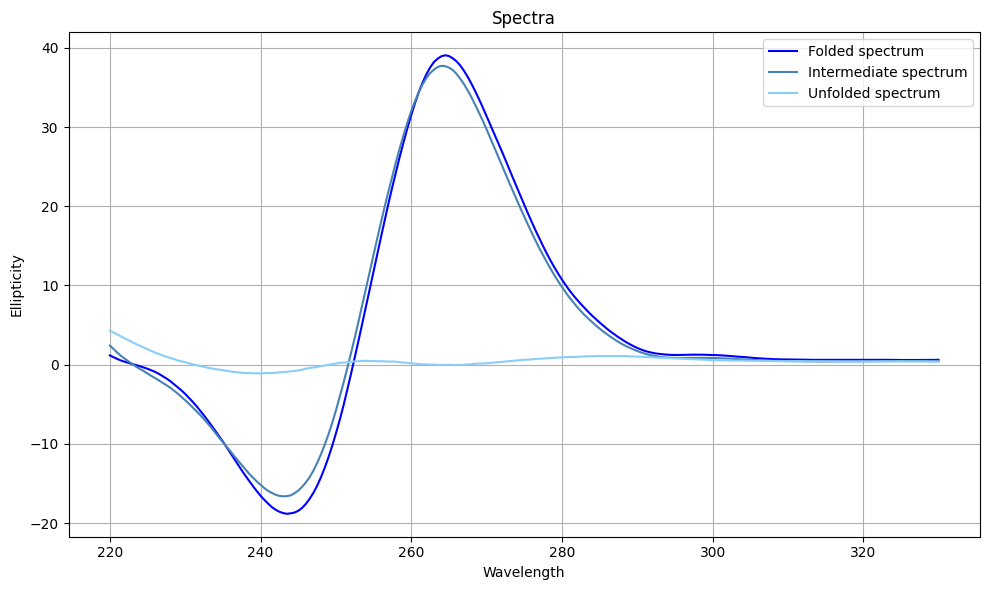

In [5]:
s_f = parametri_dict['C11']*U_prime.iloc[:, 0] + parametri_dict['C21']*U_prime.iloc[:, 1] + parametri_dict['C31']*U_prime.iloc[:, 2]
s_i = parametri_dict['C12']*U_prime.iloc[:, 0] + parametri_dict['C22']*U_prime.iloc[:, 1] + parametri_dict['C32']*U_prime.iloc[:, 2]
s_u = parametri_dict['C13']*U_prime.iloc[:, 0] + parametri_dict['C23']*U_prime.iloc[:, 1] + parametri_dict['C33']*U_prime.iloc[:, 2]

# Creo un array con le lunghezze d'onda da mettere sulle x
#  Al fine di rendere anche grafico successivo sensato fisicamente è necessario inserire sull'asse delle x le T
# e quindi caricare i dati di temperatura
matr = pd.read_csv('matrice_con_t.dat', sep=',', header=None)
t_array = matr.iloc[0, 1:].astype(float).values # prima riga, salto il primo elemento
l_array = matr.iloc[1:, 0].str.replace(',', '.').astype(float).values


plt.figure(figsize=(10, 6))
plt.plot(l_array, s_f, label='Folded spectrum', color='blue')
plt.plot(l_array, s_i, label='Intermediate spectrum', color='steelblue')
plt.plot(l_array, s_u, label='Unfolded spectrum', color='lightskyblue')

plt.title('Spectra')
plt.xlabel('Wavelength')
plt.ylabel('Ellipticity')
plt.legend()
plt.grid()
plt.tight_layout() 
plt.show()

## Andamenti in funzione della temperatura:

### Popolazione degli stati:

Questa sezione, invece, si concentrerà nello studiare gli andamenti in funzione della temperatura: 

La prima cosa che verrà studiata è M: una matrice di dimensioni (3xlen_T). Questa racchiude informazioni fisiche estremamente interessanti, infatti plottando le 3 componenti di M lungo la temperatura scopriremo le popolazioni corrispettivamente dei 3 stati analizzati: 
folded,
intermediate e
unfolded,
in funzione di T.

Cioè: $M_1 = pop(T)_f$, $M_2 = pop(T)_i$ e $M_3 = pop(T)_u$.

In [6]:
M_file = Path("M_matrix.csv")

M = pd.read_csv(M_file, sep="\t", header=None)

M.head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,8.953807e-01,8.802798e-01,8.635728e-01,8.452073e-01,8.251542e-01,8.034125e-01,7.800130e-01,7.550209e-01,7.285377e-01,0.700701,...,0.109212,0.086562,0.065358,0.046906,0.032097,0.021101,0.013455,0.008400,0.005174,0.003164
1,1.046193e-01,1.197202e-01,1.364272e-01,1.547927e-01,1.748458e-01,1.965874e-01,2.199869e-01,2.449789e-01,2.714618e-01,0.299298,...,0.637889,0.560766,0.469072,0.372520,0.281771,0.204530,0.143844,0.098939,0.067080,0.045098
2,1.120921e-09,2.522883e-09,5.603283e-09,1.228086e-08,2.656271e-08,5.670079e-08,1.194529e-07,2.483801e-07,5.097724e-07,0.000001,...,0.252899,0.352672,0.465570,0.580574,0.686132,0.774369,0.842702,0.892662,0.927746,0.951739


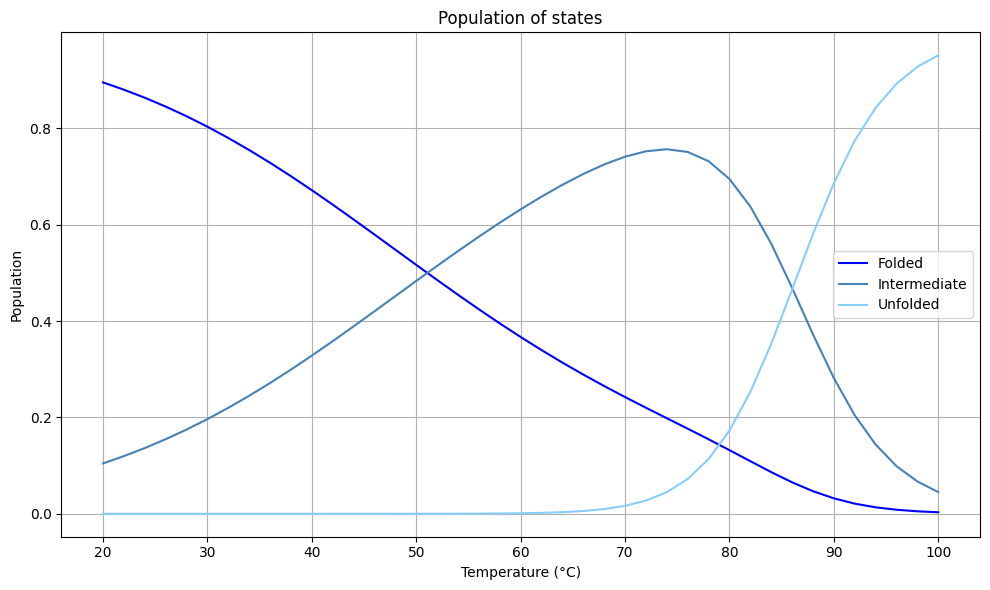

In [7]:
M_1 = M.iloc[0,:].values
M_2 = M.iloc[1,:].values
M_3 = M.iloc[2,:].values

plt.figure(figsize=(10, 6))
plt.plot(t_array, M_1, label='Folded', color='blue')
plt.plot(t_array, M_2, label='Intermediate', color='steelblue')
plt.plot(t_array, M_3, label='Unfolded', color='lightskyblue')

plt.title('Population of states')
plt.xlabel('Temperature (°C)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Andamento spettri in funzione della T:

Per trattare questa ultima parte è necessario fare delle considerazioni: 
1) Al fine di trattare i vari spettri in funzione della temperatura si è usato: 'ipywidgets';
2) Per confrontare i risultati si sono utilizzati due metodi che teoricamente dovrebbero fornire lo stesso risultato, ovvero l'andamento degli spettri alle varie temperature:
    - Ricostruzione 1: $Spettro_{f,i,u}(\lambda) \times M(T)$
    - Ricostruzione 2: $ U'(\lambda) \times f(T) $

Con $f_i(T) = \sum_{j=1}^{3} C_{ij} \cdot M_j(T)$

**RICOSTRUZIONE 1**


In [8]:
import ipywidgets as widgets
import numpy as np

# Recupera parametri
Tm1 = parametri_dict['Tm1']
Tm2 = parametri_dict['Tm2']
dH1 = parametri_dict['dH1']
dH2 = parametri_dict['dH2']
R = 1.987

# Funzione per calcolare M_i a singola temperatura
def calc_M_i_single(T):
    A = np.exp(-dH1 / R * (1/Tm1 - 1/T))
    B = np.exp(-dH2 / R * (1/Tm2 - 1/T))
    denom = 1 + A + A*B
    M1 = 1 / denom
    M2 = A / denom
    M3 = A*B / denom
    return M1, M2, M3

@widgets.interact(idx=widgets.IntSlider(min=0, max=len(t_array)-1, step=1, value=0))
def plot_spettro_interattivo1(idx):
    T = t_array[idx] +273.15  # Converti in Kelvin
    M1, M2, M3 = calc_M_i_single(T)

    spettro1 = M1 * s_f + M2 * s_i + M3 * s_u

    plt.figure(figsize=(10, 5))
    plt.plot(l_array, spettro1, label=f"T = {t_array[idx]:.1f} °C", color='royalblue')
    plt.xlabel("Lunghezza d’onda (nm)")
    plt.ylabel("Ellitticità")
    plt.title("Spettro simulato in funzione della temperatura")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

**RICOSTRUZIONE 2**

In [9]:
@widgets.interact(idx=widgets.IntSlider(min=0, max=len(t_array)-1, step=1, value=0))
def plot_spettro_interattivo2(idx):
    T = t_array[idx] + 273.15  # Kelvin
    M1, M2, M3 = calc_M_i_single(T)
    M_vec = np.array([M1, M2, M3])  # shape (3,)

    # Costruzione C
    C = np.array([
        [parametri_dict['C11'], parametri_dict['C12'], parametri_dict['C13']],
        [parametri_dict['C21'], parametri_dict['C22'], parametri_dict['C23']],
        [parametri_dict['C31'], parametri_dict['C32'], parametri_dict['C33']],
    ])

    f_T = C @ M_vec  # shape (3,)

    # spettro simulato = combinazione lineare delle componenti SVD (U') con f_T
    spettro2 = U_prime @ f_T  # shape: (n_lambda,)

    plt.figure(figsize=(10, 5))
    plt.plot(l_array, spettro2, label=f"T = {t_array[idx]:.1f} °C", color='sandybrown')
    plt.xlabel("Lunghezza d’onda (nm)")
    plt.ylabel("Ellitticità")
    plt.title("Ricostruzione spettro simulato in funzione della temperatura")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

plottiamoli insieme:

In [10]:
# Funzione per calcolare spettro 1
def plot_spettro1(T):
    M1, M2, M3 = calc_M_i_single(T)
    spettro1 = M1 * s_f + M2 * s_i + M3 * s_u
    return spettro1

# Funzione per calcolare spettro 2
def plot_spettro2(T):
    M1, M2, M3 = calc_M_i_single(T)
    M_vec = np.array([M1, M2, M3])  # shape (3,)

    # Costruzione C
    C = np.array([
        [parametri_dict['C11'], parametri_dict['C12'], parametri_dict['C13']],
        [parametri_dict['C21'], parametri_dict['C22'], parametri_dict['C23']],
        [parametri_dict['C31'], parametri_dict['C32'], parametri_dict['C33']],
    ])

    f_T = C @ M_vec  # shape (3,)
    
    # spettro simulato = combinazione lineare delle componenti SVD (U') con f_T
    spettro2 = U_prime @ f_T  # shape: (n_lambda,) → perfetta per plot con l_array

    return spettro2

@widgets.interact(idx=widgets.IntSlider(min=0, max=len(t_array)-1, step=1, value=0))
def plot_spettro_combinato(idx):
    T = t_array[idx] + 273.15  # Converti in Kelvin

    # Spettro 1
    spettro1 = plot_spettro1(T)
    
    # Spettro 2
    spettro2 = plot_spettro2(T)

    # Creazione del grafico
    plt.figure(figsize=(10, 6))

    # Plot spettro1
    plt.plot(l_array, spettro1, label=f"Spettro 1 (T = {t_array[idx]:.1f} °C)", color='royalblue')

    # Plot spettro2
    plt.plot(l_array, spettro2, label=f"Spettro 2 (T = {t_array[idx]:.1f} °C)", color='sandybrown')

    plt.xlabel("Lunghezza d’onda (nm)")
    plt.ylabel("Ellitticità")
    plt.title("Confronto tra due spettri simulati in funzione della temperatura")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

Ora al fine di verificare quanto la ricostruzione spettrale si discosti dallo spettro vero, si è deciso di plottare i due sullo stesso grafico e far stampare, inoltre, gli errori.

In questo caso preciso si è deciso di utilizzare sia il MAE che l'MSE, per avere un quadro più completo.
Dare uno sguardo a questi scarti ci permette, infatti, di quantificare la bontà del modello ricostruito.

**MAE (Mean Absolute Error)**:
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$
Questo è lo scarto medio, estremamente intuitivo che ci dà una stima di quanto il modello è errato in media.


**MSE (Mean Standard Error)**
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$
Questo errore anche se meno intuitivo fa sì che gli errori più grandi (quindi quei valori che si discostano di più dal modello) siano di più penalizzati. 


Un riscontro tra i due ci può fornire anche la quantità di errori gravi che il modello (spettro ricostruito) compie.

In [11]:
dati_file = Path("dati_puliti.csv")

dati_puliti = pd.read_csv(dati_file, sep="\t", header=None)

dati_puliti.head() 

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.690073,0.594515,0.558850,0.539230,0.518909,0.572465,0.529252,0.535038,0.553952,0.578594,...,0.482802,0.474593,0.412534,0.449928,0.433836,0.416314,0.422019,0.356426,0.416018,0.359595
1,0.690435,0.605249,0.545716,0.544413,0.530282,0.549292,0.512822,0.514569,0.552011,0.599670,...,0.480866,0.474701,0.424608,0.454074,0.441275,0.443013,0.404459,0.364644,0.390242,0.364532
2,0.697104,0.613594,0.539834,0.542031,0.552200,0.523191,0.511314,0.504031,0.539964,0.604565,...,0.471653,0.470591,0.426925,0.445359,0.448967,0.440004,0.402753,0.397843,0.378232,0.359207
3,0.687360,0.599005,0.534644,0.524888,0.520019,0.512783,0.497171,0.504198,0.544028,0.599380,...,0.476281,0.479963,0.441010,0.425127,0.451567,0.448670,0.423389,0.416523,0.403924,0.375066
4,0.689045,0.607496,0.542317,0.513248,0.514410,0.496625,0.485801,0.506105,0.547135,0.585067,...,0.473911,0.487527,0.455050,0.417484,0.442674,0.456393,0.439601,0.426258,0.418330,0.381205


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

@widgets.interact(idx=widgets.IntSlider(min=0, max=len(t_array)-1, step=1, value=0))
def plot_confronto_spettri(idx):
    T = t_array[idx] + 273.15  # Kelvin

    # Calcolo spettro simulato
    spettro_ricostruito = plot_spettro1(T)  # output: array (n_lambda,)

    # Estrai spettro reale corrispondente
    spettro_reale = dati_puliti.iloc[:, idx].values  # Assumi colonne = spettri a varie T

    # Calcolo scarti
    mae = mean_absolute_error(spettro_reale, spettro_ricostruito)
    mse = mean_squared_error(spettro_reale, spettro_ricostruito)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(l_array, spettro_ricostruito, color='orange', label="Spettro Simulato")
    plt.plot(l_array, spettro_reale, label="Spettro reale", color='blue', linestyle='dashed')
    plt.fill_between(l_array, spettro_ricostruito, spettro_reale, color='gray', alpha=0.3, label=f'Scarto (MAE={mae:.3f}, MSE={mse:.3f})')
    plt.title(f"T = {t_array[idx]:.1f} °C ")
    plt.xlabel("Lunghezza d’onda (nm)")
    plt.ylabel("Ellitticità")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

## Inclusione errori sperimentali (Monte Carlo)

In questa sezione verranno inclusi gli errori sperimentali simulati nel software di fit. 
Caricati gli errori saranno:
1) Confrontati visivamente al fine di capire qualitativamente se siano più o meno impattanti degli errori del fit (già stimati sopra);
2) Gli errori verranno poi valutati e confrontati con gli errori di fit.

In [13]:
param_file = Path("parametri_con_errori.csv")

parametri_completi = pd.read_csv(
    param_file,
    sep="\t",
    header=None,
    names=["Parametro", "Media", "Dev_std", "Fonte"]
)
parametri_completi.drop(0, axis=0, inplace=True)  # Rimuovo la riga con i titoli
parametri_completi.head()

,Parametro,Media,Dev_std,Fonte
1,C11,0.18078006088426432,0.015353411115725088,secondo fit
2,C12,0.1736153754017992,0.016704816019972136,secondo fit
3,C13,0.00309964665798532,0.01945655304260773,secondo fit
4,C21,-0.06670423256621935,0.016518176947518448,secondo fit
5,C22,0.011391519277627125,0.017859979186163888,secondo fit


L'incertezza sullo spettro ricostruito è stata propagata secondo la formula per variabili indipendenti: $\sigma_S^2 = \sum_k (a_k \cdot \sigma_k)^2$, come discusso in CITA[Taylor, J. R., "An Introduction to Error Analysis", University Science Books].


In [14]:
media_dict = dict(zip(parametri_completi["Parametro"], parametri_completi["Media"].astype(float)))
std_dict = dict(zip(parametri_completi["Parametro"], parametri_completi["Dev_std"].astype(float)))



def banda_errore_spettro(T_kelvin):
    M1, M2, M3 = calc_M_i_single(T_kelvin)
    M_vec = np.array([M1, M2, M3])
    spettro_varianza = np.zeros(U_prime.shape[0])

    for i in range(3):
        for j in range(3):
            nome = f"C{i+1}{j+1}"
            sigma = std_dict[nome]
            spettro_varianza += (sigma * M_vec[j])**2 * U_prime.iloc[:, i]**2

    spettro_std = np.sqrt(spettro_varianza)
    return spettro_std



@widgets.interact(idx=widgets.IntSlider(min=0, max=len(t_array)-1, step=1, value=0))
def plot_spettro_con_errori(idx):
    T_kelvin = t_array[idx] + 273.15
    spettro = plot_spettro1(T_kelvin)
    errore = banda_errore_spettro(T_kelvin)
    spettro_reale = dati_puliti.iloc[:, idx].values

    plt.figure(figsize=(10, 5))
    plt.plot(l_array, spettro, label="Spettro ricostruito", color='darkorange')
    plt.fill_between(l_array, spettro - errore, spettro + errore, alpha=0.3, color='orange', label='±1σ')
    plt.plot(l_array, spettro_reale, label="Spettro reale", color='darkblue', linestyle='dashed')
    plt.title(f"Spettro ricostruito con banda d'errore (T = {t_array[idx]:.1f} °C)")
    plt.xlabel("Lunghezza d’onda (nm)")
    plt.ylabel("Ellitticità")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

In [15]:
rapporti = []

for i in range(len(t_array)):
    T_kelvin = t_array[i] + 273.15
    
    # Spettro reale
    spettro_reale = dati_puliti.iloc[:, i].values
    
    # Spettro simulato con errori
    spettro_fit = plot_spettro1(T_kelvin)
    spettro_sigma = banda_errore_spettro(T_kelvin)
    
    mae = mean_absolute_error(spettro_reale, spettro_fit)
    errore_medio_sigma = np.mean(spettro_sigma)
    
    rapporto = mae / errore_medio_sigma if errore_medio_sigma > 0 else np.nan
    rapporti.append(rapporto)

# Output sintetico
rapporti = np.array(rapporti)
print("Media MAE / Errore atteso:", np.nanmean(rapporti))
print("Range:", np.nanmin(rapporti), "–", np.nanmax(rapporti))

Media MAE / Errore atteso: 0.12032076017466757
Range: 0.07932609690584538 – 0.16917304893713964


Il MAE risulta in media solo il 12% dell'errore stimato.
Il fit è signicativamente entro le bande di errore e le incertezze ottenute grazie al metodo Monte Carlo non sono sottostimate. 

Il range osservato (0.079–0.166) conferma che, in tutti i casi, lo scostamento tra spettro simulato e reale rimane entro i limiti previsti, garantendo così una validità statistica e fisica al modello proposto.